# 01 EDA: what does delivery demand look like? (Casablanca)

**Data note:** semi-synthetic. Real weather and calendar, simulated orders and couriers. Not company data.

Goal: read the series by eye before modelling: trend, daily and weekly seasonality, and the effects of rain, Ramadan and payday.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from config import DATA_NOTE
from simulate import RAIN_MM
from calendar_features import check_time_index

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

def label(fig):
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    fig.text(0.01, 0.01, DATA_NOTE, fontsize=8, color='gray')

df = pd.read_parquet('../data/processed/demand_casablanca.parquet')
df['date'] = df['timestamp'].dt.tz_localize(None).dt.normalize()
df['raining'] = df['precipitation'] > RAIN_MM
df.head()

,timestamp,timestamp_utc,orders,orders_completed,couriers_online,temperature_2m,precipitation,rain,rain_forecast,hour,dow,is_holiday,holiday_name,is_ramadan,is_payday_window,is_promo,date,raining
0,2024-10-02 00:00:00+01:00,2024-10-01 23:00:00+00:00,84,84,26,19.4,0.0,0.0,False,0,2,False,,False,True,False,2024-10-02,False
1,2024-10-02 01:00:00+01:00,2024-10-02 00:00:00+00:00,26,26,21,18.5,0.0,0.0,False,1,2,False,,False,True,False,2024-10-02,False
2,2024-10-02 02:00:00+01:00,2024-10-02 01:00:00+00:00,28,28,15,18.4,0.0,0.0,False,2,2,False,,False,True,False,2024-10-02,False
3,2024-10-02 03:00:00+01:00,2024-10-02 02:00:00+00:00,33,33,19,18.1,0.0,0.0,False,3,2,False,,False,True,False,2024-10-02,False
4,2024-10-02 04:00:00+01:00,2024-10-02 03:00:00+00:00,41,41,12,17.8,0.0,0.0,False,4,2,False,,False,True,False,2024-10-02,False


## 0. Data quality: the time index
Before any chart, check the clock. Morocco moves its clock around Ramadan (and, per tzdata 2026.5, permanently to UTC+0 on 2026-09-20). The data is stored in UTC and converted to local time.

In [2]:
info = check_time_index(df)
print('UTC steps between rows:', info['utc_steps'])
local_hour = df['timestamp'].dt.strftime('%Y-%m-%d %H:00')
print('local hours that appear twice:', local_hour[local_hour.duplicated()].tolist())
info['clock_shifts']

UTC steps between rows: ['0 days 01:00:00']
local hours that appear twice: ['2025-02-23 02:00', '2026-02-15 02:00', '2026-09-20 01:00']


,timestamp_utc,timestamp
3459,2025-02-23 02:00:00+00:00,2025-02-23 02:00:00+00:00
4467,2025-04-06 02:00:00+00:00,2025-04-06 03:00:00+01:00
12027,2026-02-15 02:00:00+00:00,2026-02-15 02:00:00+00:00
12867,2026-03-22 02:00:00+00:00,2026-03-22 03:00:00+01:00
17234,2026-09-20 01:00:00+00:00,2026-09-20 01:00:00+00:00


**Takeaway:** UTC has no gaps (every step is exactly 1 hour). The local clock shifts 5 times: three times back, so one local hour appears twice, and twice forward, so one local hour is skipped. That's why the data is stored in UTC and local time is used only for hour-of-day and calendar features. Any "same hour last week" lookup (like the seasonal-naive baseline) must use local time, or it is an hour off for a week after each shift.

## 1. Daily orders over time
Trend plus weekly wiggle. Also look for anything odd: dips, bumps, steps.

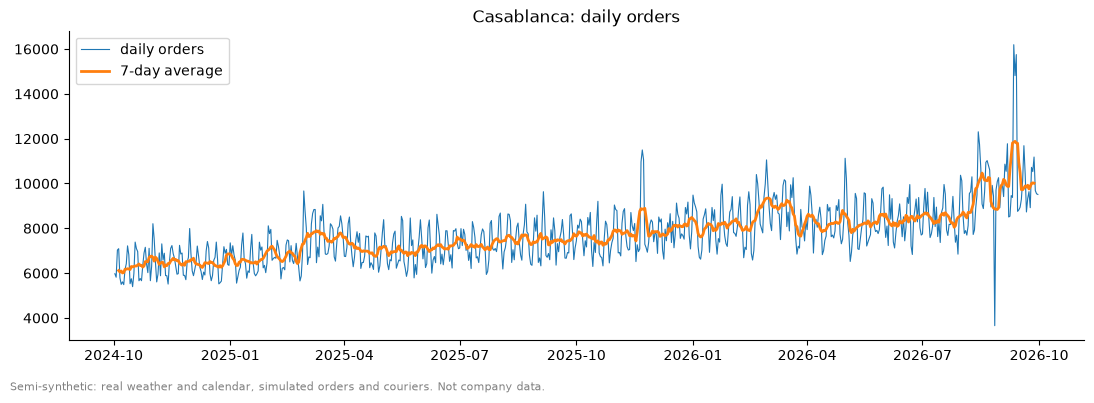

(date
 2026-08-27    3657
 2024-10-16    5398
 2024-10-09    5488
 Name: orders, dtype: int64,
 date
 2026-09-12    14814
 2026-09-13    15751
 2026-09-11    16192
 Name: orders, dtype: int64)

In [3]:
daily = df.groupby('date')['orders'].sum()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily.values, lw=0.8, label='daily orders')
ax.plot(daily.index, daily.rolling(7, center=True).mean(), lw=2, label='7-day average')
ax.set_title('Casablanca: daily orders'); ax.legend(); label(fig)
plt.show()
daily.sort_values().head(3), daily.sort_values().tail(3)

**Takeaway:** a steady upward trend (growth) with a weekly rhythm. Ramadan (Mar 2025, Feb-Mar 2026) does not dip the daily total; it nudges it up, so the totals hide a big change in the hourly shape (see chart 5). The three-day bump in late November 2025 is a known promo (it is on the promo calendar, `promo_calendar.csv`). Near the end there are oddities (a one-day crash, a few unusually high days, a step up) that no calendar or weather feature explains. We will come back to them in the miss investigation, not now.

## 2. Hour x weekday heatmap
When do people order?

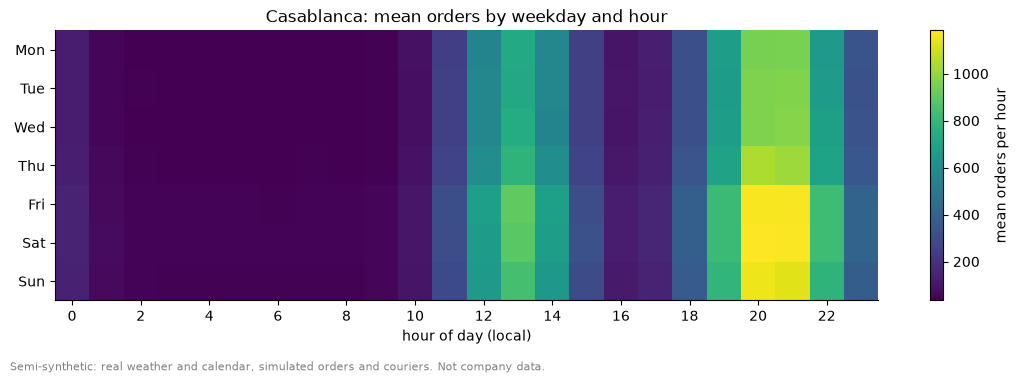

In [4]:
heat = df.pivot_table(index='dow', columns='hour', values='orders', aggfunc='mean')
fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(7)); ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('hour of day (local)')
fig.colorbar(im, label='mean orders per hour'); ax.set_title('Casablanca: mean orders by weekday and hour'); label(fig)
plt.show()

**Takeaway:** two peaks (lunch about 13:00, dinner about 20:30-21:00), near-silent nights, and Friday to Sunday stronger. Hour and weekday are the backbone of any model.

## 3. Rain vs no rain
Same hour of day, rainy hours vs dry hours (non-holiday, non-Ramadan, before the end-of-period oddities).

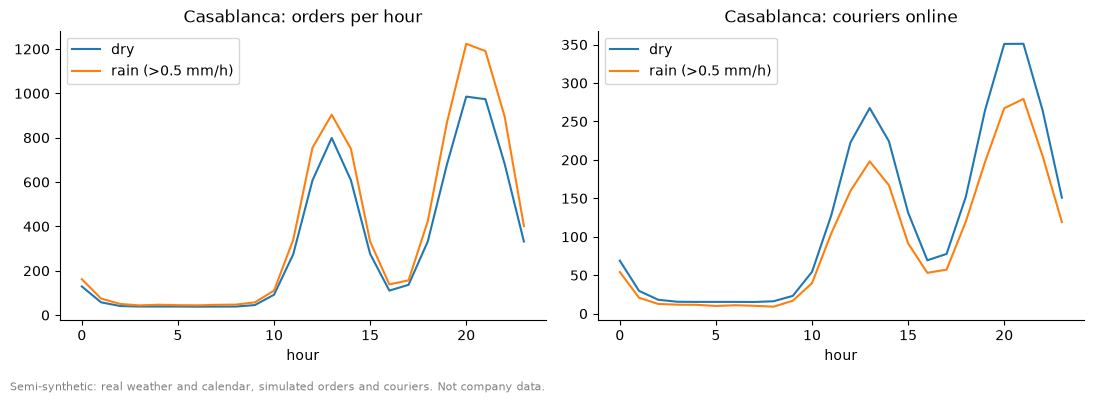

rainy hours per hour of day, 12-22: [9, 10, 10, 10, 11, 14, 16, 10, 14, 12, 14]


([1.24, 1.13, 1.23, 1.2, 1.25, 1.15, 1.27, 1.28, 1.24, 1.22, 1.31],
 [0.72, 0.74, 0.74, 0.7, 0.76, 0.74, 0.79, 0.75, 0.76, 0.8, 0.78])

In [5]:
base = df[(~df.is_ramadan) & (~df.is_holiday) & (df.timestamp < '2026-08-01')]
g = base.groupby(['hour', 'raining'])[['orders', 'couriers_online']].mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['orders', 'couriers_online'], ['orders per hour', 'couriers online']):
    ax.plot(g[col][False], label='dry'); ax.plot(g[col][True], label=f'rain (>{RAIN_MM} mm/h)')
    ax.set_title(f'Casablanca: {title}'); ax.set_xlabel('hour'); ax.legend()
label(fig); plt.show()
print('rainy hours per hour of day, 12-22:', base[base.raining].groupby('hour').size().loc[12:22].tolist())
(g['orders'][True] / g['orders'][False]).loc[12:22].round(2).tolist(), (g['couriers_online'][True] / g['couriers_online'][False]).loc[12:22].round(2).tolist()

**Takeaway:** in rain, orders go up by roughly a fifth and couriers online go down by roughly a quarter, at every hour. Caveat: rain is rare in Casablanca (about 2% of hours, almost none June-September), so each hour's ratio rests on only 9-16 rainy hours; hence the wobble between 1.13 and 1.31. This is the supply/demand squeeze that makes rain the key driver to forecast.

## 4. Courier supply vs demand
Orders per online courier: a proxy for how stretched the fleet is.

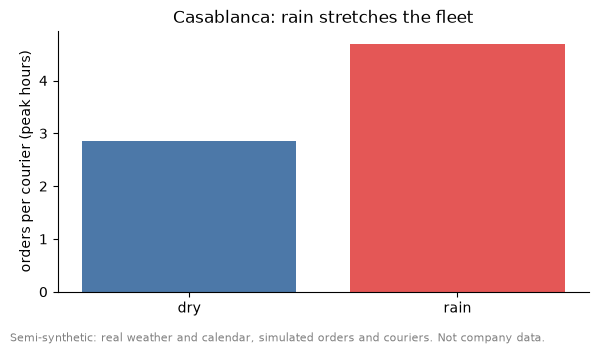

,orders,couriers_online,orders_per_courier
raining,,,
False,3461844,1213714,2.85
True,98160,20887,4.70


In [6]:
peak = df[df.hour.isin([12, 13, 14, 20, 21, 22])]
# ratio of sums (total orders / total couriers), not the mean of hourly ratios, which small denominators inflate
r = peak.groupby('raining')[['orders', 'couriers_online']].sum()
r['orders_per_courier'] = r['orders'] / r['couriers_online']
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(['dry', 'rain'], r['orders_per_courier'], color=['#4c78a8', '#e45756'])
ax.set_ylabel('orders per courier (peak hours)'); ax.set_title('Casablanca: rain stretches the fleet'); label(fig)
plt.show(); r.round(2)

**Takeaway:** each courier carries about 1.6x as many orders in rain at peak hours (more demand, fewer couriers). Under-forecasting rain means slower deliveries; this is where the ops decision (rider incentives) comes from.

## 5. Ramadan vs normal days
Share of each day's orders by hour, so overall growth does not mask the shape change.

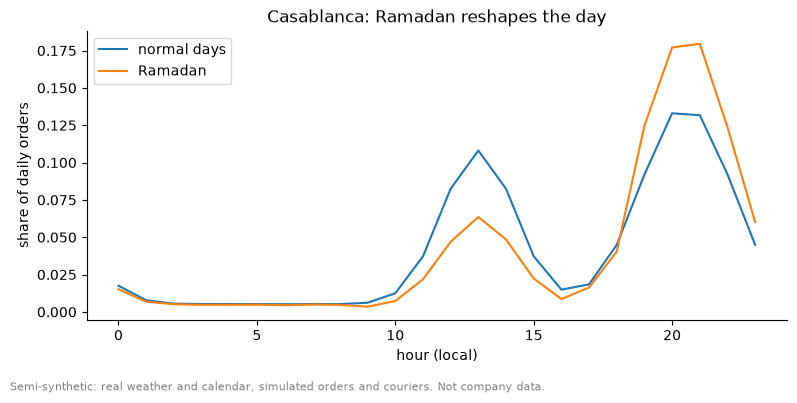

In [7]:
d = df[~df.is_holiday].copy()
d['share'] = d['orders'] / d.groupby('date')['orders'].transform('sum')
s = d.groupby(['hour', 'is_ramadan'])['share'].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s[False], label='normal days'); ax.plot(s[True], label='Ramadan')
ax.set_xlabel('hour (local)'); ax.set_ylabel('share of daily orders'); ax.legend()
ax.set_title('Casablanca: Ramadan reshapes the day'); label(fig)
plt.show()

**Takeaway:** in Ramadan the daytime share falls (the 13:00 share drops from about 11% to 6%) and the post-iftar evening (19:00-23:00) takes a much bigger share. The peak stays at about 20:00-21:00: the change is in the *size* of the peaks, not their timing. So the ops response is to move courier hours from lunch to the evening, not just add more couriers.

## 6. Payday effect
Daily orders divided by their centred 28-day average (removes trend), averaged by day of month. Aug-Sep 2026 is left out: it has the unexplained oddities seen in chart 1, which would leak into single days of the month.

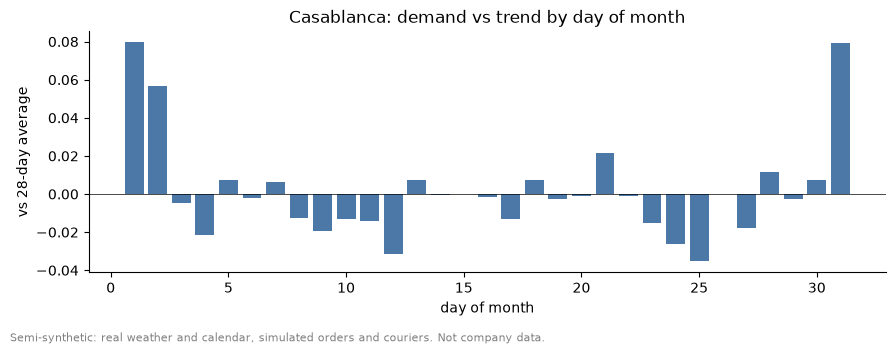

date
30    0.008
31    0.079
1     0.080
2     0.056
3    -0.005
Name: orders, dtype: float64

In [8]:
d6 = daily[:'2026-07-31']
trend = d6.rolling(28, center=True).mean()
ratio = (d6 / trend).dropna()
by_dom = ratio.groupby(ratio.index.day).mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(by_dom.index, by_dom.values - 1, color='#4c78a8')
ax.axhline(0, color='k', lw=0.5); ax.set_xlabel('day of month'); ax.set_ylabel('vs 28-day average')
ax.set_title('Casablanca: demand vs trend by day of month'); label(fig)
plt.show()
(by_dom[[30, 31, 1, 2, 3]] - 1).round(3)

**Takeaway:** a lift of about 5-8% on the last day of the month and the two days after (days 31, 1 and 2), the payday window. Day 30 is the month end in only four months a year, so it barely shows. The other days wobble by about +/-3.5%: noise plus the weekday mix, which leaks into this view. The effect is smaller than rain or Ramadan, but it repeats every month, so a model needs a payday flag to catch it.

## 7. Censored demand: what a platform would actually record
`orders` is true demand. A real platform only records completed orders, capped by how many the couriers online can carry (`orders_completed`). Compare the rain uplift in each, peak hours, same hour rainy vs dry (normal days, before the end-of-period oddities).

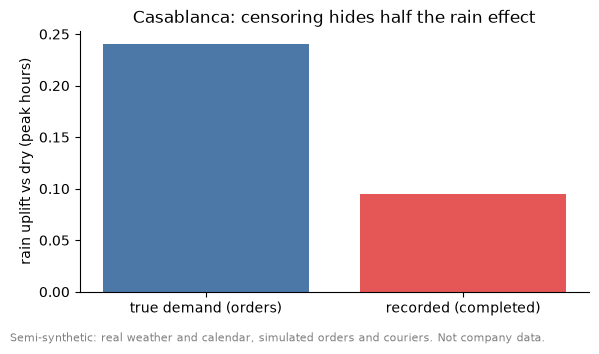

rain uplift: {'orders': 0.241, 'orders_completed': 0.094}
share of peak hours capped by couriers: dry 0.3%, rain 81.0%


In [9]:
c = df[(df.timestamp < '2026-08-01') & df.hour.isin([12, 13, 14, 19, 20, 21, 22])
       & ~df.is_holiday & ~df.is_ramadan & ~df.is_promo]
m = c.groupby(['hour', 'raining'])[['orders', 'orders_completed']].mean()
uplift = (m.xs(True, level='raining') / m.xs(False, level='raining')).mean() - 1
capped = (c['orders'] > c['orders_completed']).groupby(c['raining']).mean()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(['true demand (orders)', 'recorded (completed)'], uplift.values, color=['#4c78a8', '#e45756'])
ax.set_ylabel('rain uplift vs dry (peak hours)'); ax.set_title('Casablanca: censoring hides half the rain effect'); label(fig)
plt.show()
print('rain uplift:', uplift.round(3).to_dict())
print('share of peak hours capped by couriers: dry %.1f%%, rain %.1f%%' % (100 * capped[False], 100 * capped[True]))

**Takeaway:** in rainy peak hours true demand is about 24% higher than dry, but recorded (completed) orders are only about 9% higher: couriers hit their capacity in 81% of rainy peak hours (0.3% when dry). A model trained on recorded orders would learn well under half the real rain effect and under-forecast exactly when the fleet is short. That is why this project forecasts demand (`orders`), and why with real data I would treat capped hours as lower bounds, not as true demand.